# 04 · Upstream normalization transforms (adaptive-normalization angle)

The net-DV01 **level** is near-integrated; a 3y z-score normalises away the very trend that *is* the
signal. Three transforms (`positioning.versions.transforms`) make it stationary-but-memory-bearing,
comparable through time, and robust to CFTC spikes:
- **fracdiff** — minimal-`d` fractional differencing (López de Prado): stationary while keeping >~long memory.
- **volscale** — divide by trailing EWMA vol (RiskMetrics): a "2σ crowd" means the same in 2008/2020/2022.
- **robust** — median/MAD z: one dislocation can't desensitise the detector.

In [1]:
import sys, os
# Make the notebook self-sufficient: walk up from cwd to the repo root (dir containing `positioning`).
_root = os.getcwd()
while _root != os.path.dirname(_root) and not os.path.isdir(os.path.join(_root, "positioning")):
    _root = os.path.dirname(_root)
if _root not in sys.path:
    sys.path.insert(0, _root)

import warnings; warnings.filterwarnings("ignore")
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
try:
    from IPython.display import display
except Exception:
    def display(x): print(x)

plt.rcParams.update({
    "figure.figsize": (11, 4.2), "figure.dpi": 110, "axes.grid": True,
    "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
})
ORANGE="#FF8200"; GREY="#3C3C3C"; BLUE="#1F4E79"; RED="#C00000"; GREEN="#2E7D32"; PURPLE="#7030A0"; TEAL="#0F9D9D"

from positioning.versions import base, compare, richness, dsp, transforms
from positioning.versions import params as P
from positioning.versions.base import responsiveness

def show(df, n=None):
    """Render a DataFrame/dict, truncated."""
    try:
        display(df if n is None else df.head(n))
    except Exception:
        print(df)

def zline(ax, bounded=False):
    """Draw crowd bands for a composite axis."""
    if bounded:
        ax.axhline(80, color=RED, ls="--", lw=0.7); ax.axhline(20, color=GREEN, ls="--", lw=0.7)
    else:
        for k in (1.5, -1.5): ax.axhline(k, color=GREY, ls="--", lw=0.6)
        ax.axhline(0, color=GREY, lw=0.4)

def crossings(z, level=0.0):
    """Count sign changes of (z-level): a proxy for 'deviations per unit time'."""
    s = z.dropna().astype(float) - level
    return int((np.sign(s).diff().abs() > 0).sum())

print("loaded versions package — building shared inputs (cache-first)…")
inp = base.load_inputs()
y10 = inp.y10_w
print(f"inputs: {len(inp.report_dates)} weekly dates {inp.report_dates.min().date()}..{inp.report_dates.max().date()}")

loaded versions package — building shared inputs (cache-first)…


inputs: 422 weekly dates 2018-06-19..2026-07-14


## The buy-side net-DV01 signal, raw vs each transform

raw ADF p=0.415  ->  min-d=0.7  ADF p=0.002  corr(raw)=0.44


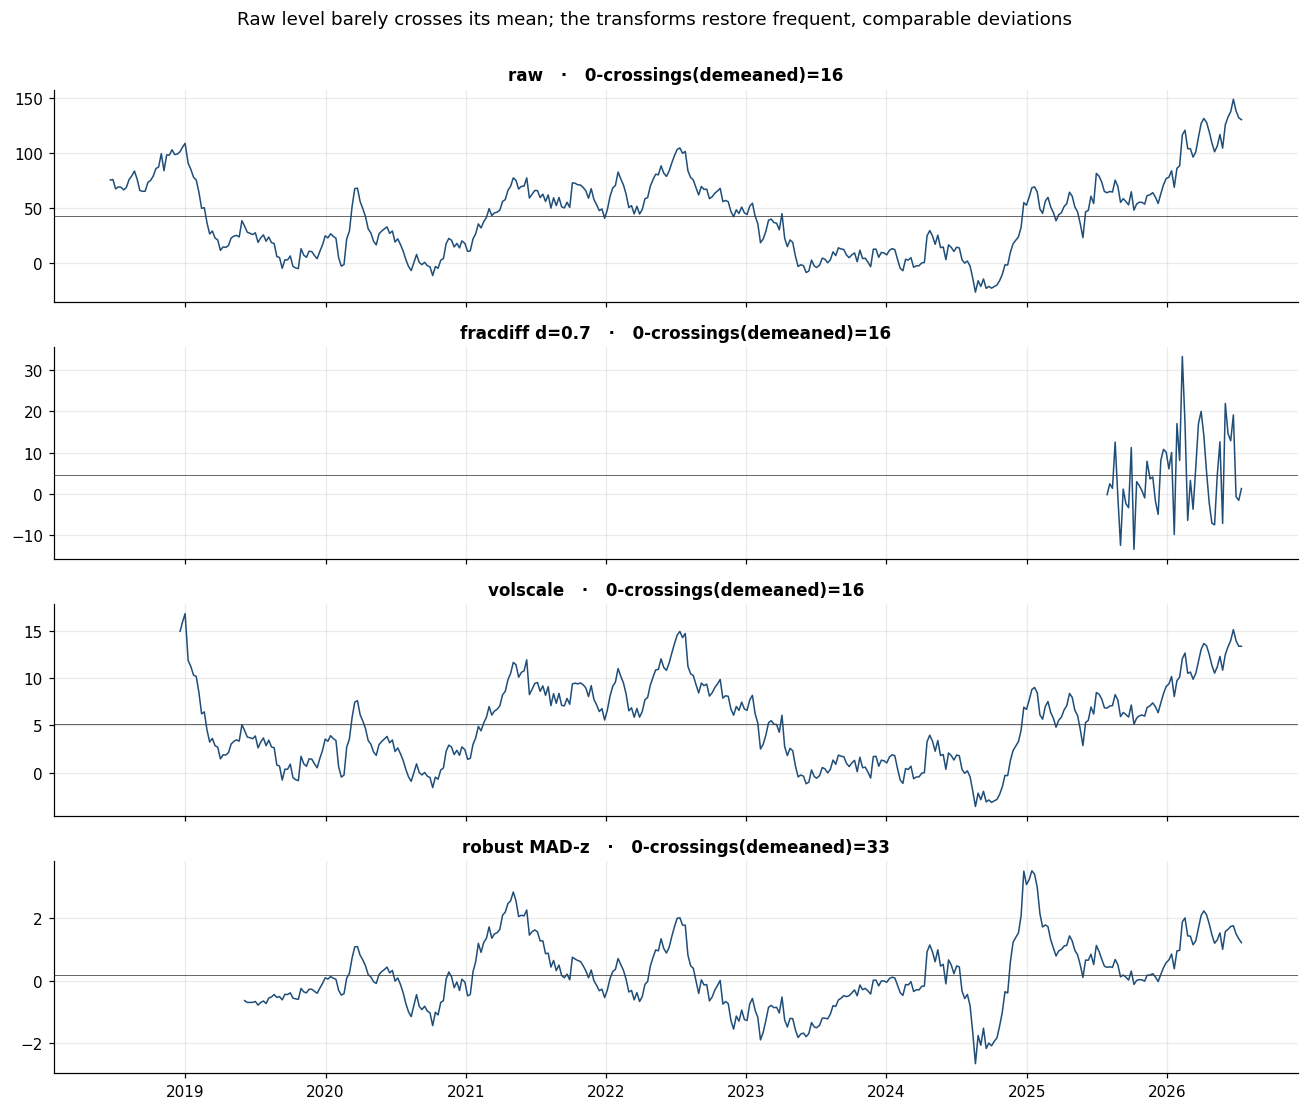

In [2]:
p = P.merge("v6", None)                       # default categories/signal_mode
sig = P.resolve_signal(inp, p).dropna()
from statsmodels.tsa.stattools import adfuller
ffd = transforms.min_ffd_d(sig)
print(f"raw ADF p={adfuller(sig.values, maxlag=1, autolag=None)[1]:.3f}  ->  "
      f"min-d={ffd['d']}  ADF p={ffd['adf_p']:.3f}  corr(raw)={ffd['corr']:.2f}")

series = {
    "raw": sig,
    f"fracdiff d={ffd['d']}": ffd["series"].dropna(),
    "volscale": transforms.ewma_vol_scale(sig).dropna(),
    "robust MAD-z": transforms.robust_mad_z(sig).dropna(),
}
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
for ax, (name, s) in zip(axes, series.items()):
    ax.plot(s.index, s.values, color=BLUE, lw=1.0)
    ax.axhline(s.mean(), color=GREY, lw=0.5)
    ax.set_title(f"{name}   ·   0-crossings(demeaned)={crossings(s - s.mean())}")
fig.suptitle("Raw level barely crosses its mean; the transforms restore frequent, comparable deviations", y=1.005)
fig.tight_layout(); display(fig); plt.close(fig)

## Does each transform's extra crossing come with information? (IC vs forward Δ10Y)

In [3]:
rows = []
for name, s in series.items():
    z = richness.to_z(s, False)
    icm = richness.ic_metrics(z, inp.y10_w, horizons=(8,), bounded=False)
    st  = richness.structure_metrics(z)
    rows.append({"transform": name, "0-cross": crossings(z),
                 "half_life_wk": st.get("ou_half_life_wk"),
                 "spec_entropy": st.get("spectral_entropy"),
                 "IC_8w": icm.get("8", {}).get("ic"), "IC_t": icm.get("8", {}).get("t")})
show(pd.DataFrame(rows).round(3))

,transform,0-cross,half_life_wk,spec_entropy,IC_8w,IC_t
0,raw,28,37.758,0.315,-0.090,-0.174
1,fracdiff d=0.7,23,0.866,0.871,0.027,0.130
2,volscale,28,21.499,0.318,-0.064,-0.135
3,robust MAD-z,37,16.348,0.503,-0.192,-0.483


### Reading it
`fracdiff` should add crossings while *keeping* IC (memory-bearing), whereas a transform that only
adds crossings with IC→0 is injecting noise (rising spectral entropy, sub-week half-life). These
transforms are exposed as the shared `norm_mode` knob on V6/V7/V8 — the notebooks above build variants
with `{'norm_mode': 'fracdiff'}` etc.